# Étape 3 — Construction du benchmark de retrieval

Ce notebook ne construit pas encore un moteur de recherche. Il prépare son **examen** : pour chaque réponse agent de MultiDoc2Dial, il conserve la question utilisateur, l’historique antérieur, la réponse de référence et les spans attendus, puis identifie les chunks qui contiennent ces spans dans chacune des quatre stratégies.

Les splits officiels `train`, `validation` et `test` sont strictement conservés. La réponse cible n’est jamais ajoutée à la requête. Les répétitions textuelles exactes entre splits sont annotées dans chaque exemple afin de permettre une analyse de sensibilité sans modifier le benchmark officiel.

## 1. Dépendances

In [1]:
%pip install -q pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import hashlib
import json
import re
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATASET_ROOT = PROJECT_ROOT / "data" / "processed" / "multidoc2dial_v1"
CONFIG_PATH = PROJECT_ROOT / "configs" / "retrieval_benchmark.json"

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset      : {DATASET_ROOT}")
print(f"Configuration: {CONFIG_PATH}")

Project root : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant
Dataset      : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\processed\multidoc2dial_v1
Configuration: C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\configs\retrieval_benchmark.json


## 2. Chargement strict des entrées versionnées

In [3]:
def load_json(path: Path) -> dict[str, Any]:
    with path.open(encoding="utf-8") as handle:
        value = json.load(handle)
    if not isinstance(value, dict):
        raise TypeError(f"La racine de {path} doit être un objet JSON")
    return value


def iter_jsonl(path: Path) -> Iterable[dict[str, Any]]:
    with path.open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as error:
                raise ValueError(f"JSONL invalide : {path}, ligne {line_number}") from error


def load_jsonl(path: Path) -> list[dict[str, Any]]:
    return list(iter_jsonl(path))


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while block := handle.read(1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def stable_hash(value: Any) -> str:
    payload = json.dumps(value, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def normalized_text(text: str) -> str:
    return " ".join(text.casefold().split())


def canonical_id(entity: str, *parts: str) -> str:
    payload = "\x1f".join((entity, *parts)).encode("utf-8")
    return f"{entity}_{hashlib.sha256(payload).hexdigest()[:24]}"


config = load_json(CONFIG_PATH)
config_hash = stable_hash(config)
stage1_manifest = load_json(DATASET_ROOT / "manifest.json")
if stage1_manifest.get("quality", {}).get("status") != "passed":
    raise RuntimeError("L’étape 1 doit être valide avant de construire le benchmark.")

conversations_path = DATASET_ROOT / "conversations.jsonl"
expected_conversations_hash = stage1_manifest["outputs"]["conversations.jsonl"]["sha256"]
assert file_sha256(conversations_path) == expected_conversations_hash
conversations = load_jsonl(conversations_path)
assert len(conversations) == stage1_manifest["outputs"]["conversations.jsonl"]["records"]

expected_document_hash = stage1_manifest["outputs"]["documents.jsonl"]["sha256"]
chunking_root = DATASET_ROOT / "chunking_experiments" / config["chunking_experiment_id"]
if not chunking_root.exists():
    raise FileNotFoundError(f"Expérience de chunking introuvable : {chunking_root}")

print(f"Conversations : {len(conversations):,}")
print(f"SHA-256       : {expected_conversations_hash}")
print(f"Chunking      : {config['chunking_experiment_id']}")

Conversations : 4,796
SHA-256       : faf10d1b3922b50bcbf768afb0b1e8258e26c20314efcc1177cdcd0f3232e67a
Chunking      : chunking_candidates_v0_b1ac9cc451


## 3. Chargement des chunks utilisés pour le retrieval

Pour une stratégie plate, le retriever cherchera dans `chunks.jsonl`. Pour la stratégie hiérarchique, il cherchera dans les `child_chunks`; les parents serviront plus tard à enrichir le contexte après retrieval.

In [4]:
strategy_chunks: dict[str, list[dict[str, Any]]] = {}
strategy_inputs: dict[str, dict[str, Any]] = {}
chunking_configuration_hashes = set()

for strategy_name in config["strategies"]:
    strategy_dir = chunking_root / strategy_name
    manifest = load_json(strategy_dir / "manifest.json")
    if manifest.get("quality", {}).get("status") != "passed":
        raise RuntimeError(f"Stratégie de chunking non valide : {strategy_name}")
    if manifest["input"]["sha256"] != expected_document_hash:
        raise RuntimeError(f"Documents incompatibles pour {strategy_name}")
    if manifest["experiment_id"] != config["chunking_experiment_id"]:
        raise RuntimeError(f"Mauvais experiment_id pour {strategy_name}")

    kind = manifest["configuration"]["kind"]
    artifact_name = "child_chunks.jsonl" if kind == "hierarchical" else "chunks.jsonl"
    retrieval_level = "child" if kind == "hierarchical" else "flat"
    artifact_path = strategy_dir / artifact_name
    metadata = manifest["outputs"][artifact_name]
    if file_sha256(artifact_path) != metadata["sha256"]:
        raise RuntimeError(f"Hash invalide : {artifact_path}")

    chunks = load_jsonl(artifact_path)
    assert len(chunks) == metadata["records"]
    assert all(chunk["strategy"] == strategy_name for chunk in chunks)
    assert all(chunk["level"] == retrieval_level for chunk in chunks)
    strategy_chunks[strategy_name] = chunks
    strategy_inputs[strategy_name] = {
        "artifact": str(artifact_path.relative_to(PROJECT_ROOT)),
        "artifact_name": artifact_name,
        "retrieval_level": retrieval_level,
        "records": len(chunks),
        "sha256": metadata["sha256"],
        "manifest_sha256": file_sha256(strategy_dir / "manifest.json"),
    }
    chunking_configuration_hashes.add(manifest["configuration_hash"])
    print(f"{strategy_name:24s} {len(chunks):>6,} chunks ({retrieval_level})")

assert len(chunking_configuration_hashes) == 1, "Les stratégies ne viennent pas de la même expérience"
chunking_configuration_hash = next(iter(chunking_configuration_hashes))
benchmark_fingerprint = stable_hash({
    "configuration": config,
    "conversations_sha256": expected_conversations_hash,
    "chunking_configuration_hash": chunking_configuration_hash,
    "strategy_artifacts": {name: value["sha256"] for name, value in strategy_inputs.items()},
})
benchmark_id = f"{config['benchmark_name']}_{benchmark_fingerprint[:10]}"
OUTPUT_ROOT = DATASET_ROOT / "retrieval_benchmarks" / benchmark_id
REPORT_ROOT = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1" / "retrieval_benchmarks" / benchmark_id
print(f"Benchmark ID: {benchmark_id}")

fixed_v1                  2,370 chunks (flat)
structure_aware_v1        3,219 chunks (flat)
section_preserving_v1     1,273 chunks (flat)
hierarchical_v1           3,265 chunks (child)
Benchmark ID: multidoc2dial_retrieval_benchmark_v1_e8baf6e2ad


## 4. Index span → chunks attendus

In [5]:
span_to_chunks: dict[str, dict[str, list[str]]] = {}
span_to_fully_containing_chunks: dict[str, dict[str, list[str]]] = {}
chunk_to_parent: dict[str, dict[str, str]] = {}
chunk_ids_by_strategy: dict[str, set[str]] = {}

for strategy_name, chunks in strategy_chunks.items():
    any_index: dict[str, list[str]] = defaultdict(list)
    full_index: dict[str, list[str]] = defaultdict(list)
    parents = {}
    for chunk in chunks:
        for span_id in chunk["source_span_ids"]:
            any_index[span_id].append(chunk["id"])
        for span_id in chunk["fully_contained_span_ids"]:
            full_index[span_id].append(chunk["id"])
        if chunk.get("parent_id"):
            parents[chunk["id"]] = chunk["parent_id"]
    span_to_chunks[strategy_name] = {key: sorted(set(value)) for key, value in any_index.items()}
    span_to_fully_containing_chunks[strategy_name] = {
        key: sorted(set(value)) for key, value in full_index.items()
    }
    chunk_to_parent[strategy_name] = parents
    chunk_ids_by_strategy[strategy_name] = {chunk["id"] for chunk in chunks}

    print(
        f"{strategy_name:24s} spans mappés={len(any_index):>6,} | "
        f"entièrement contenus={len(full_index):>6,}"
    )

fixed_v1                 spans mappés=35,659 | entièrement contenus=35,652
structure_aware_v1       spans mappés=35,659 | entièrement contenus=35,659
section_preserving_v1    spans mappés=35,659 | entièrement contenus=35,659
hierarchical_v1          spans mappés=35,659 | entièrement contenus=35,659


## 5. Construction des exemples

La `query` est le dernier tour utilisateur avant la réponse cible. `history` contient uniquement ce qui précède cette query. Pour une continuation d’agent, les tours situés entre la query et la cible sont conservés séparément dans `intermediate_turns`.

In [6]:
def compact_turn(turn: dict[str, Any]) -> dict[str, Any]:
    return {
        "turn_id": turn["id"],
        "index": turn["index"],
        "role": turn["role"],
        "dialogue_act": turn["dialogue_act"],
        "text": turn["utterance"].strip(),
    }


def reference_key(reference: dict[str, Any]) -> tuple[str, str, str]:
    return (reference["document_id"], reference["section_id"], reference["span_id"])


def compact_reference(reference: dict[str, Any]) -> dict[str, Any]:
    return {
        "document_id": reference["document_id"],
        "section_id": reference["section_id"],
        "span_id": reference["span_id"],
        "label": reference["label"],
        "source_document_id": reference["source_document_id"],
        "source_span_id": reference["source_span_id"],
    }


examples = []
skipped_without_user = []
short_query_limit = config["diagnostics"]["short_query_max_words"]

for conversation in conversations:
    turns = conversation["turns"]
    for target_position, target in enumerate(turns):
        if target["role"] != config["target_role"]:
            continue

        user_positions = [
            position for position in range(target_position) if turns[position]["role"] == "user"
        ]
        if not user_positions:
            skipped_without_user.append({"conversation_id": conversation["id"], "target_turn_id": target["id"]})
            continue
        query_position = user_positions[-1]
        query_turn = turns[query_position]
        directly_follows_user = query_position == target_position - 1
        cohort = "direct_user_response" if directly_follows_user else "agent_continuation"
        if cohort == "agent_continuation" and not config["include_agent_continuations"]:
            continue

        references = sorted(
            {reference_key(reference): reference for reference in target["references"]}.values(),
            key=reference_key,
        )
        if not references:
            raise ValueError(f"Réponse cible sans référence : {target['id']}")
        if config["require_resolved_references"] and any(not reference["is_resolved"] for reference in references):
            raise ValueError(f"Référence non résolue : {target['id']}")

        gold_span_ids = sorted({reference["span_id"] for reference in references})
        gold_document_ids = sorted({reference["document_id"] for reference in references})
        gold_section_ids = sorted({reference["section_id"] for reference in references})
        strategy_ground_truth = {}
        for strategy_name in config["strategies"]:
            span_mapping = []
            relevant_chunk_ids = set()
            fully_containing_chunk_ids = set()
            for span_id in gold_span_ids:
                any_chunks = span_to_chunks[strategy_name].get(span_id, [])
                full_chunks = span_to_fully_containing_chunks[strategy_name].get(span_id, [])
                relevant_chunk_ids.update(any_chunks)
                fully_containing_chunk_ids.update(full_chunks)
                span_mapping.append({
                    "span_id": span_id,
                    "chunk_ids": any_chunks,
                    "fully_containing_chunk_ids": full_chunks,
                })
            relevant_chunk_ids = sorted(relevant_chunk_ids)
            strategy_ground_truth[strategy_name] = {
                "retrieval_level": strategy_inputs[strategy_name]["retrieval_level"],
                "relevant_chunk_ids": relevant_chunk_ids,
                "fully_containing_chunk_ids": sorted(fully_containing_chunk_ids),
                "relevant_parent_chunk_ids": sorted({
                    chunk_to_parent[strategy_name][chunk_id]
                    for chunk_id in relevant_chunk_ids
                    if chunk_id in chunk_to_parent[strategy_name]
                }),
                "span_mapping": span_mapping,
            }

        query_text = query_turn["utterance"].strip()
        answer_text = target["utterance"].strip()
        word_count = len(re.findall(r"\b\w+\b", query_text, flags=re.UNICODE))
        examples.append({
            "schema_version": "1.0.0",
            "id": canonical_id("eval", conversation["id"], target["id"]),
            "benchmark_id": benchmark_id,
            "split": conversation["split"],
            "domain": conversation["domain"],
            "conversation_id": conversation["id"],
            "source_dialogue_id": conversation["source_dialogue_id"],
            "cohort": cohort,
            "query": {
                **compact_turn(query_turn),
                "word_count": word_count,
                "is_short": word_count <= short_query_limit,
                "is_response_act": query_turn["dialogue_act"].startswith("response_"),
                "text_hash": hashlib.sha256(normalized_text(query_text).encode("utf-8")).hexdigest(),
            },
            "history": [compact_turn(turn) for turn in turns[:query_position]],
            "intermediate_turns": [compact_turn(turn) for turn in turns[query_position + 1:target_position]],
            "target": {
                **compact_turn(target),
                "reference_answer": answer_text,
            },
            "gold": {
                "document_ids": gold_document_ids,
                "section_ids": gold_section_ids,
                "span_ids": gold_span_ids,
                "references": [compact_reference(reference) for reference in references],
            },
            "strategy_ground_truth": strategy_ground_truth,
            "diagnostics": {
                "target_directly_follows_user": directly_follows_user,
                "history_turn_count": query_position,
                "intermediate_turn_count": target_position - query_position - 1,
                "query_answer_pair_hash": hashlib.sha256(
                    f"{normalized_text(query_text)}\x1f{normalized_text(answer_text)}".encode("utf-8")
                ).hexdigest(),
            },
        })

print(f"Exemples construits       : {len(examples):,}")
print(f"Sans utilisateur antérieur: {len(skipped_without_user):,}")

Exemples construits       : 33,869
Sans utilisateur antérieur: 0


## 6. Quality gates bloquants

In [7]:
quality_errors = []
example_ids = [example["id"] for example in examples]
if len(example_ids) != len(set(example_ids)):
    quality_errors.append("duplicate_example_ids")
if skipped_without_user:
    quality_errors.append(f"agent_targets_without_prior_user:{len(skipped_without_user)}")

expected_splits = set(config["splits"])
actual_splits = {example["split"] for example in examples}
if actual_splits != expected_splits:
    quality_errors.append(f"unexpected_splits:{sorted(actual_splits)}")

conversation_splits: dict[str, set[str]] = defaultdict(set)
for example in examples:
    conversation_splits[example["conversation_id"]].add(example["split"])
cross_split_conversations = {key: value for key, value in conversation_splits.items() if len(value) > 1}
if cross_split_conversations:
    quality_errors.append(f"conversations_in_multiple_splits:{len(cross_split_conversations)}")

mapping_failures = []
hidden_target_failures = []
for example in examples:
    visible_turn_ids = {turn["turn_id"] for turn in [*example["history"], *example["intermediate_turns"]]}
    visible_turn_ids.add(example["query"]["turn_id"])
    if example["target"]["turn_id"] in visible_turn_ids:
        hidden_target_failures.append(example["id"])

    gold_span_ids = set(example["gold"]["span_ids"])
    for strategy_name, ground_truth in example["strategy_ground_truth"].items():
        mapped_span_ids = {
            item["span_id"] for item in ground_truth["span_mapping"] if item["chunk_ids"]
        }
        if mapped_span_ids != gold_span_ids:
            mapping_failures.append((example["id"], strategy_name, sorted(gold_span_ids - mapped_span_ids)))
        if not set(ground_truth["relevant_chunk_ids"]) <= chunk_ids_by_strategy[strategy_name]:
            mapping_failures.append((example["id"], strategy_name, ["unknown_chunk_id"]))

if hidden_target_failures:
    quality_errors.append(f"target_leakage_into_input:{len(hidden_target_failures)}")
if mapping_failures:
    quality_errors.append(f"gold_span_mapping_failures:{len(mapping_failures)}")

quality_status = "passed" if not quality_errors else "failed"
print(f"Quality status : {quality_status}")
print(f"Erreurs        : {quality_errors}")
if quality_errors:
    display(pd.DataFrame(mapping_failures[:50], columns=["example_id", "strategy", "missing"]))
    raise ValueError("Quality gates du benchmark échoués")
print("✅ Toutes les questions ont des références valides dans les quatre stratégies.")

Quality status : passed
Erreurs        : []
✅ Toutes les questions ont des références valides dans les quatre stratégies.


## 7. Profil du benchmark et audit des répétitions entre splits

In [8]:
profile_rows = []
for example in examples:
    profile_rows.append({
        "id": example["id"],
        "split": example["split"],
        "domain": example["domain"],
        "conversation_id": example["conversation_id"],
        "cohort": example["cohort"],
        "target_dialogue_act": example["target"]["dialogue_act"],
        "query_words": example["query"]["word_count"],
        "is_short_query": example["query"]["is_short"],
        "is_response_act": example["query"]["is_response_act"],
        "history_turns": len(example["history"]),
        "intermediate_turns": len(example["intermediate_turns"]),
        "gold_documents": len(example["gold"]["document_ids"]),
        "gold_spans": len(example["gold"]["span_ids"]),
        "query_hash": example["query"]["text_hash"],
        "query_answer_pair_hash": example["diagnostics"]["query_answer_pair_hash"],
    })
profile_df = pd.DataFrame(profile_rows)

split_profile = profile_df.groupby("split").agg(
    examples=("id", "count"),
    conversations=("conversation_id", "nunique"),
    direct_user_responses=("cohort", lambda values: int((values == "direct_user_response").sum())),
    agent_continuations=("cohort", lambda values: int((values == "agent_continuation").sum())),
    short_queries=("is_short_query", "sum"),
    mean_history_turns=("history_turns", "mean"),
    mean_gold_spans=("gold_spans", "mean"),
).round(2)
display(split_profile)
display(pd.crosstab(profile_df["domain"], profile_df["split"], margins=True))
display(profile_df["target_dialogue_act"].value_counts().to_frame("examples"))

def cross_split_shared_hashes(column: str) -> set[str]:
    split_counts = profile_df.groupby(column)["split"].nunique()
    return set(split_counts[split_counts > 1].index)


shared_query_hashes = cross_split_shared_hashes("query_hash")
shared_query_answer_pair_hashes = cross_split_shared_hashes("query_answer_pair_hash")
for example in examples:
    query_overlap = example["query"]["text_hash"] in shared_query_hashes
    pair_overlap = example["diagnostics"]["query_answer_pair_hash"] in shared_query_answer_pair_hashes
    example["diagnostics"]["exact_query_shared_across_splits"] = query_overlap
    example["diagnostics"]["exact_query_answer_pair_shared_across_splits"] = pair_overlap
    example["diagnostics"]["exact_text_overlap_free"] = not query_overlap and not pair_overlap

profile_df["exact_query_shared_across_splits"] = profile_df["query_hash"].isin(shared_query_hashes)
profile_df["exact_query_answer_pair_shared_across_splits"] = profile_df["query_answer_pair_hash"].isin(
    shared_query_answer_pair_hashes
)
profile_df["exact_text_overlap_free"] = ~(
    profile_df["exact_query_shared_across_splits"]
    | profile_df["exact_query_answer_pair_shared_across_splits"]
)

overlap_profile = profile_df.groupby("split").agg(
    examples=("id", "count"),
    exact_query_overlap=("exact_query_shared_across_splits", "sum"),
    exact_query_answer_overlap=("exact_query_answer_pair_shared_across_splits", "sum"),
    exact_text_overlap_free=("exact_text_overlap_free", "sum"),
)
overlap_profile["primary_exact_text_overlap_free"] = [
    int(((profile_df["split"] == split) & (profile_df["cohort"] == config["primary_cohort"])
         & profile_df["exact_text_overlap_free"]).sum())
    for split in overlap_profile.index
]
display(overlap_profile)

leakage_audit = {
    "conversation_ids_shared_across_splits": len(cross_split_conversations),
    "exact_queries_shared_across_splits": {
        "shared_unique_hashes": len(shared_query_hashes),
        "affected_examples": int(profile_df["exact_query_shared_across_splits"].sum()),
    },
    "exact_query_answer_pairs_shared_across_splits": {
        "shared_unique_hashes": len(shared_query_answer_pair_hashes),
        "affected_examples": int(profile_df["exact_query_answer_pair_shared_across_splits"].sum()),
    },
    "overlap_profile_by_split": overlap_profile.reset_index().to_dict(orient="records"),
    "interpretation": (
        "Les conversations restent disjointes. Les répétitions textuelles éventuelles entre splits sont "
        "signalées pour les analyses de sensibilité, sans modifier les splits officiels."
    ),
}
assert all(
    "exact_text_overlap_free" in example["diagnostics"]
    and "exact_query_shared_across_splits" in example["diagnostics"]
    and "exact_query_answer_pair_shared_across_splits" in example["diagnostics"]
    for example in examples
)
print(json.dumps(leakage_audit, ensure_ascii=False, indent=2))

,examples,conversations,direct_user_responses,agent_continuations,short_queries,mean_history_turns,mean_gold_spans
split,,,,,,,
test,4567,661,4335,232,869,5.74,1.55
train,24603,3474,22806,1797,4002,5.88,1.60
validation,4699,661,4427,272,816,5.95,1.59


split,test,train,validation,All
domain,,,,
dmv,1139,6975,1218,9332
ssa,1226,5751,1236,8213
studentaid,890,4718,920,6528
va,1312,7159,1325,9796
All,4567,24603,4699,33869


,examples
target_dialogue_act,
respond_solution,23209
query_condition,7750
respond_no_solution,1822
respond_solution_positive,629
respond_solution_negative,459


,examples,exact_query_overlap,exact_query_answer_overlap,exact_text_overlap_free,primary_exact_text_overlap_free
split,,,,,
test,4567,652,144,3915,3702
train,24603,2580,543,22023,20294
validation,4699,594,140,4105,3850


{
  "conversation_ids_shared_across_splits": 0,
  "exact_queries_shared_across_splits": {
    "shared_unique_hashes": 318,
    "affected_examples": 3826
  },
  "exact_query_answer_pairs_shared_across_splits": {
    "shared_unique_hashes": 126,
    "affected_examples": 827
  },
  "overlap_profile_by_split": [
    {
      "split": "test",
      "examples": 4567,
      "exact_query_overlap": 652,
      "exact_query_answer_overlap": 144,
      "exact_text_overlap_free": 3915,
      "primary_exact_text_overlap_free": 3702
    },
    {
      "split": "train",
      "examples": 24603,
      "exact_query_overlap": 2580,
      "exact_query_answer_overlap": 543,
      "exact_text_overlap_free": 22023,
      "primary_exact_text_overlap_free": 20294
    },
    {
      "split": "validation",
      "examples": 4699,
      "exact_query_overlap": 594,
      "exact_query_answer_overlap": 140,
      "exact_text_overlap_free": 4105,
      "primary_exact_text_overlap_free": 3850
    }
  ],
  "interpretati

,retrieval_chunks,mean_relevant_chunks_per_example,max_relevant_chunks_per_example,gold_span_occurrences_without_full_containment
strategy,,,,
fixed_v1,2370,1.230,2,16
structure_aware_v1,3219,1.268,16,0
section_preserving_v1,1273,1.042,10,0
hierarchical_v1,3265,1.261,16,0


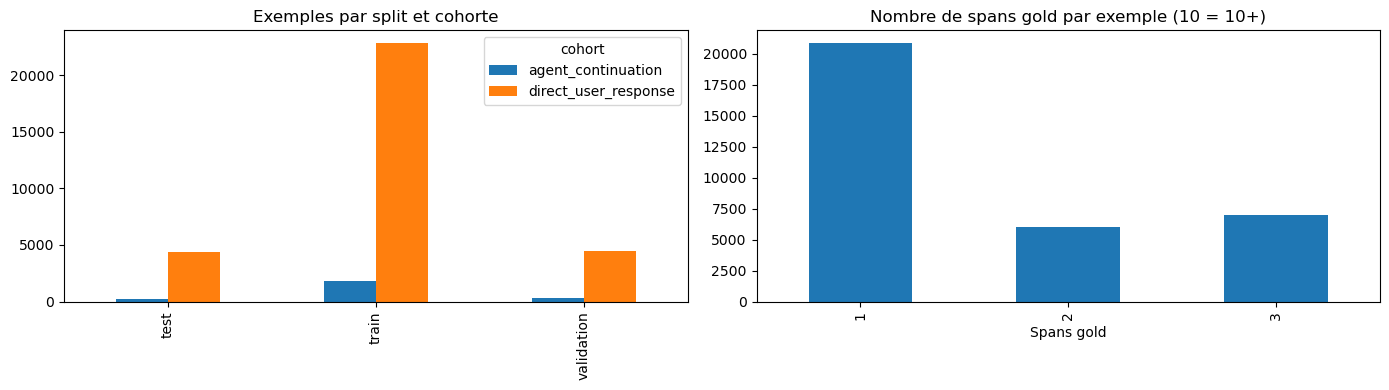

In [9]:
mapping_rows = []
full_containment_gaps = {}
for strategy_name in config["strategies"]:
    relevant_counts = []
    fully_containing_counts = []
    spans_without_full_containment = 0
    for example in examples:
        ground_truth = example["strategy_ground_truth"][strategy_name]
        relevant_counts.append(len(ground_truth["relevant_chunk_ids"]))
        fully_containing_counts.append(len(ground_truth["fully_containing_chunk_ids"]))
        spans_without_full_containment += sum(
            not item["fully_containing_chunk_ids"] for item in ground_truth["span_mapping"]
        )
    full_containment_gaps[strategy_name] = spans_without_full_containment
    mapping_rows.append({
        "strategy": strategy_name,
        "retrieval_chunks": len(strategy_chunks[strategy_name]),
        "mean_relevant_chunks_per_example": round(sum(relevant_counts) / len(relevant_counts), 3),
        "max_relevant_chunks_per_example": max(relevant_counts),
        "gold_span_occurrences_without_full_containment": spans_without_full_containment,
    })
mapping_df = pd.DataFrame(mapping_rows).set_index("strategy")
display(mapping_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.crosstab(profile_df["split"], profile_df["cohort"]).plot.bar(ax=axes[0])
profile_df["gold_spans"].clip(upper=10).value_counts().sort_index().plot.bar(ax=axes[1])
axes[0].set_title("Exemples par split et cohorte")
axes[0].set_xlabel("")
axes[1].set_title("Nombre de spans gold par exemple (10 = 10+)")
axes[1].set_xlabel("Spans gold")
plt.tight_layout()
plt.show()

## 8. Inspection de cas réels

In [10]:
def example_summary(example: dict[str, Any]) -> dict[str, Any]:
    return {
        "id": example["id"],
        "split": example["split"],
        "domain": example["domain"],
        "cohort": example["cohort"],
        "history_tail": " | ".join(
            f"{turn['role']}: {turn['text']}" for turn in example["history"][-3:]
        ),
        "query": example["query"]["text"],
        "reference_answer": example["target"]["reference_answer"],
        "gold_spans": len(example["gold"]["span_ids"]),
        **{
            f"chunks_{strategy_name}": len(example["strategy_ground_truth"][strategy_name]["relevant_chunk_ids"])
            for strategy_name in config["strategies"]
        },
    }


normal_example = next(
    example for example in examples
    if example["cohort"] == "direct_user_response" and not example["query"]["is_short"] and example["history"]
)
short_contextual_example = next(
    example for example in examples
    if example["cohort"] == "direct_user_response" and example["query"]["is_short"] and example["history"]
)
continuation_example = next(example for example in examples if example["cohort"] == "agent_continuation")
display(pd.DataFrame([
    example_summary(normal_example),
    example_summary(short_contextual_example),
    example_summary(continuation_example),
]))

,id,split,domain,cohort,history_tail,query,reference_answer,gold_spans,chunks_fixed_v1,chunks_structure_aware_v1,chunks_section_preserving_v1,chunks_hierarchical_v1
0,eval_e617c46e74ac53a256f68a95,test,dmv,direct_user_response,"agent: Is your snowmobile registered in your home state? | user: No, currently not. | agent: Unfortunately, no relevant information is f...",Can you suggest a topic to me?,Registration.,1,1,1,1,1
1,eval_4bfbed0b2f88756e1760f177,test,dmv,direct_user_response,user: What can you tell me about registering a snowmobile? | agent: Is your snowmobile registered in your home state?,"No, currently not.","Unfortunately, no relevant information is found.",1,1,5,2,5
2,eval_e2e40c2499560a8841aee82d,test,dmv,agent_continuation,,What are the fees for commercial vehicles?,Is this the original registration of your vehicle?,1,1,1,1,1


## 9. Écriture atomique et manifeste

In [11]:
def write_jsonl_atomic(path: Path, records: Iterable[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8", newline="\n") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")
    temporary.replace(path)


def write_json_atomic(path: Path, value: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    temporary.replace(path)


generated_at = datetime.now(timezone.utc).isoformat()
output_metadata = {}
for split in config["splits"]:
    records = [example for example in examples if example["split"] == split]
    output_path = OUTPUT_ROOT / f"{split}.jsonl"
    write_jsonl_atomic(output_path, records)
    output_metadata[output_path.name] = {
        "records": len(records),
        "bytes": output_path.stat().st_size,
        "sha256": file_sha256(output_path),
    }

quality = {
    "status": quality_status,
    "errors": quality_errors,
    "target_leakage_failures": len(hidden_target_failures),
    "gold_span_mapping_failures": len(mapping_failures),
    "conversations_shared_across_splits": len(cross_split_conversations),
    "full_containment_gaps_by_strategy": full_containment_gaps,
}
manifest = {
    "schema_version": "1.0.0",
    "pipeline_stage": "03_build_retrieval_benchmark",
    "generated_at_utc": generated_at,
    "benchmark_id": benchmark_id,
    "benchmark_fingerprint": benchmark_fingerprint,
    "implementation_version": config["implementation_version"],
    "configuration_path": str(CONFIG_PATH.relative_to(PROJECT_ROOT)),
    "configuration_hash": config_hash,
    "inputs": {
        "conversations": {
            "path": str(conversations_path.relative_to(PROJECT_ROOT)),
            "records": len(conversations),
            "sha256": expected_conversations_hash,
        },
        "documents_sha256": expected_document_hash,
        "chunking_experiment_id": config["chunking_experiment_id"],
        "chunking_configuration_hash": chunking_configuration_hash,
        "strategies": strategy_inputs,
    },
    "outputs": output_metadata,
    "counts": {
        "examples": len(examples),
        "primary_cohort_examples": int((profile_df["cohort"] == config["primary_cohort"]).sum()),
        "agent_continuations": int((profile_df["cohort"] == "agent_continuation").sum()),
        "by_split": profile_df["split"].value_counts().sort_index().to_dict(),
        "by_domain": profile_df["domain"].value_counts().sort_index().to_dict(),
    },
    "leakage_audit": leakage_audit,
    "mapping_metrics": mapping_rows,
    "quality": quality,
    "status": "ready_for_retrieval_evaluation",
}
write_json_atomic(OUTPUT_ROOT / "manifest.json", manifest)

report = {
    **manifest,
    "split_profile": split_profile.reset_index().to_dict(orient="records"),
    "dialogue_act_counts": profile_df["target_dialogue_act"].value_counts().to_dict(),
}
write_json_atomic(REPORT_ROOT / "benchmark_report.json", report)

print(f"Benchmark : {OUTPUT_ROOT}")
print(f"Rapport   : {REPORT_ROOT / 'benchmark_report.json'}")

Benchmark : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\processed\multidoc2dial_v1\retrieval_benchmarks\multidoc2dial_retrieval_benchmark_v1_e8baf6e2ad
Rapport   : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\reports\generated\multidoc2dial_v1\retrieval_benchmarks\multidoc2dial_retrieval_benchmark_v1_e8baf6e2ad\benchmark_report.json


## 10. Validation après relecture depuis le disque

In [12]:
persisted_manifest = load_json(OUTPUT_ROOT / "manifest.json")
assert persisted_manifest["benchmark_id"] == benchmark_id
assert persisted_manifest["benchmark_fingerprint"] == benchmark_fingerprint
assert persisted_manifest["configuration_hash"] == config_hash
assert persisted_manifest["quality"]["status"] == "passed"
assert persisted_manifest["status"] == "ready_for_retrieval_evaluation"

persisted_ids = []
for filename, metadata in persisted_manifest["outputs"].items():
    output_path = OUTPUT_ROOT / filename
    assert file_sha256(output_path) == metadata["sha256"]
    record_count = 0
    for record in iter_jsonl(output_path):
        assert record["split"] == output_path.stem
        assert "exact_text_overlap_free" in record["diagnostics"]
        persisted_ids.append(record["id"])
        record_count += 1
    assert record_count == metadata["records"]

assert len(persisted_ids) == len(examples)
assert len(persisted_ids) == len(set(persisted_ids))
assert set(persisted_ids) == set(example_ids)
print("✅ Benchmark versionné, relu et prêt pour la baseline BM25.")

✅ Benchmark versionné, relu et prêt pour la baseline BM25.


## 11. Ce que nous utiliserons à l’étape 4

La baseline BM25 lira un split du benchmark, utilisera seulement `query.text` comme première baseline, retournera une liste ordonnée de chunks, puis comparera cette liste à `strategy_ground_truth[strategy].relevant_chunk_ids`. La cohorte principale sera `direct_user_response`; les `agent_continuation` seront rapportées séparément.